In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

In [2]:
# Load the Excel file
excel_file = pd.ExcelFile("COKE_Ablation.xlsx")

# Get the names of all sheets in the excel file
sheet_names = excel_file.sheet_names

# Create a dictionary to store all the dataframes
dfs = {}

# Load each sheet into a separate dataframe
for sheet in sheet_names:
    dfs[sheet] = pd.read_excel(excel_file, sheet_name=sheet)

# Initialize a dictionary to hold the restructured data
restructured_data = {}

# Iterate over each dataframe
for name, df in dfs.items():
    # Get the AUC values for each method
    for idx, row in df.iterrows():
        method = row.iloc[0]
        auc = row.iloc[1]

        # Initialize the dictionary for the method if necessary
        if method not in restructured_data:
            restructured_data[method] = {}

        # Add the AUC value to the restructured data
        restructured_data[method][name] = auc

# Convert the dictionary to a pandas dataframe
restructured_df = pd.DataFrame.from_dict(restructured_data, orient='index')

In [5]:
restructured_df

,heart-small,heart-full,stroke-small,stroke-full,breast-small,breast-full,wgs-small,wgs-medium,wgs-full
Full Model,0.92135,0.92685,0.79440,0.83530,0.66085,0.69045,0.54480,0.54820,0.61185
w/o Augmentation,0.91535,0.92405,0.78695,0.83480,0.65380,0.68540,0.53255,0.53800,0.59545
w/o Contrastive,0.91570,0.92160,0.77365,0.83070,0.65425,0.67445,0.54290,0.54575,0.57250
w/o Mixer,0.91930,0.92255,0.75965,0.82615,0.64705,0.66320,0.53580,0.54770,0.59670


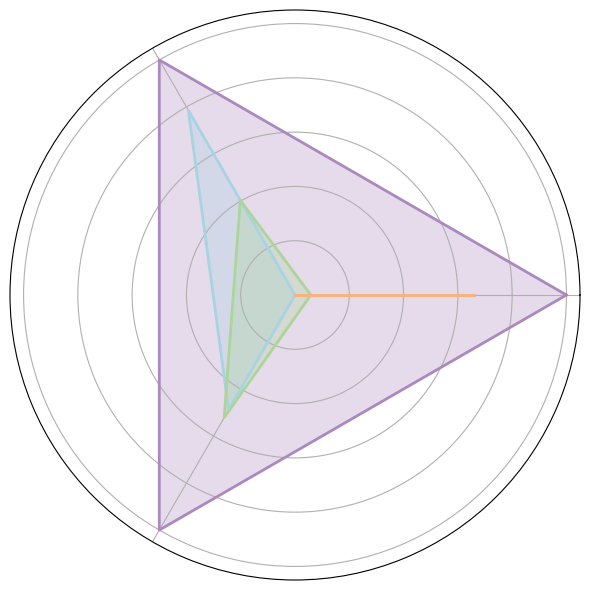

In [8]:
# Normalize the data for each axis independently
independently_normalized_df_ = restructured_df.apply(lambda col: (col - col.min()) / (col.max() - col.min()), axis=0)
# independently_normalized_df_ = restructured_df

# print(independently_normalized_df.iloc[:, :3])

independently_normalized_df = independently_normalized_df_[['heart-small', 'stroke-small', 'breast-small']]

# Get the values for the plot
values = independently_normalized_df.values

# Get the labels for the plot
# labels = independently_normalized_df.columns.values
labels = ['Heart (S)', 'Stroke (S)', 'Breast (S)']

# Create a figure for the plot
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Compute the angles for the plot
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# Ensure the plot is a complete circle
angles += angles[:1]

# Add each method to the plot
colors = ['#AB88BE', '#A8D3E3', '#ADD599', '#F6B37F']
idx=0
for method, value in zip(independently_normalized_df.index, values):
    value = np.concatenate((value, [value[0]])) 
    ax.plot(angles, value, linewidth=2, label=method, color=colors[idx])
    ax.fill(angles, value, alpha=0.3, color=colors[idx])
    idx += 1

# Arrange labels in a way to avoid overlapping with the plot lines
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=20)

# Increase the size of the radial axis labels
ax.tick_params(axis='y', labelsize=20)

# Add a legend
# ax.legend(loc='upper right', bbox_to_anchor=(1.55, 1.1), fontsize=15)
ax.set_yticklabels([])
ax.set_xticklabels([])

plt.tight_layout()
plt.savefig('benchmark_radar_small.pdf',bbox_inches = "tight",transparent=True)


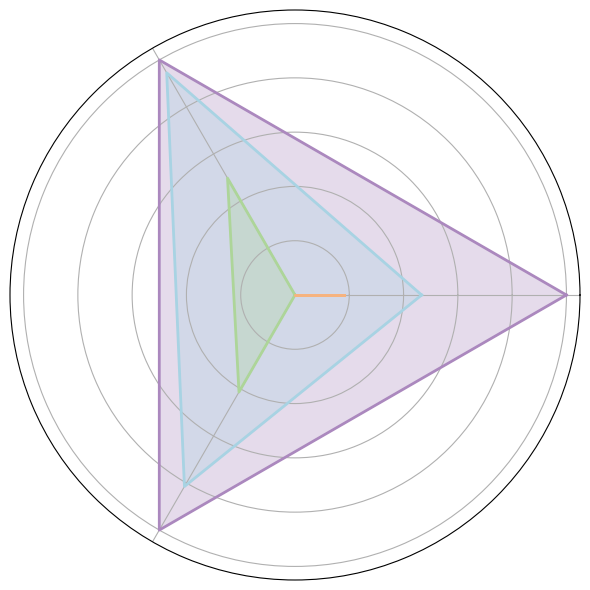

In [9]:
# Normalize the data for each axis independently
independently_normalized_df_ = restructured_df.apply(lambda col: (col - col.min()) / (col.max() - col.min()), axis=0)
# independently_normalized_df_ = restructured_df

# print(independently_normalized_df.iloc[:, :3])

independently_normalized_df = independently_normalized_df_[['heart-full', 'stroke-full', 'breast-full']]

# Get the values for the plot
values = independently_normalized_df.values

# Get the labels for the plot
# labels = independently_normalized_df.columns.values
labels = ['Heart (F)', 'Stroke (F)', 'Breast (F)']

# Create a figure for the plot
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Compute the angles for the plot
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# Ensure the plot is a complete circle
angles += angles[:1]

# Add each method to the plot
colors = ['#AB88BE', '#A8D3E3', '#ADD599', '#F6B37F']
idx=0
for method, value in zip(independently_normalized_df.index, values):
    value = np.concatenate((value, [value[0]])) 
    ax.plot(angles, value, linewidth=2, label=method, color=colors[idx])
    ax.fill(angles, value, alpha=0.3, color=colors[idx])
    idx += 1

# Arrange labels in a way to avoid overlapping with the plot lines
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=20)

# Increase the size of the radial axis labels
ax.tick_params(axis='y', labelsize=20)

# Add a legend
# ax.legend(loc='upper right', bbox_to_anchor=(1.55, 1.1), fontsize=15)
ax.set_yticklabels([])
ax.set_xticklabels([])

plt.tight_layout()
plt.savefig('benchmark_radar_full.pdf',bbox_inches = "tight",transparent=True)